In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/devashishmani1/pain-prediction-dataset-emphatica-e4/pain_dataset_200P_4hz.csv


# =========================================
# Author: Usman Shafeeq
# Project: AI-Based Pain Level Prediction from Multimodal Physiological Signals
# =========================================

## 📊 Dataset Overview

- Multimodal **physiological time-series dataset** collected using an Empatica E4 wearable device  
- Each row represents **synchronized sensor readings** at a specific time interval  
- Includes **motion data** from a 3-axis accelerometer:
  - `acc_x`, `acc_y`, `acc_z` → body movement tracking  
- Includes key **physiological signals**:
  - `eda` → electrodermal activity (stress response)  
  - `bvp` → blood volume pulse (cardiovascular activity)  
  - `hr` → heart rate (beats per minute)  
  - `temp` → skin temperature  
- Contains **person_ID** for subject identification (supports personalized modeling)  
- Target variable:
  - `pain_scale` (1–8) → self-reported pain intensity  
- Suitable for:
  - **Regression** → predict exact pain level  
  - **Classification** → categorize pain (low/medium/high)  
- Ideal for building **machine learning and deep learning models (e.g., LSTM)**  
- Enables development of **real-time pain monitoring and intelligent healthcare systems**

### 1️⃣ Import Libraries

In [23]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [22]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'   # Force CPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # Hide TensorFlow warnings

# Now import TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### 2️⃣ Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/devashishmani1/pain-prediction-dataset-emphatica-e4/pain_dataset_200P_4hz.csv")

In [3]:
df.head()

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5


### 3️⃣ Basic Dataset Info

In [10]:
# Shape
print("Dataset shape:", df.shape)

Dataset shape: (96000, 9)


In [11]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   person_ID   96000 non-null  object 
 1   acc_x       96000 non-null  float64
 2   acc_y       96000 non-null  float64
 3   acc_z       96000 non-null  float64
 4   eda         96000 non-null  float64
 5   bvp         96000 non-null  float64
 6   hr          96000 non-null  float64
 7   temp        96000 non-null  float64
 8   pain_scale  96000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.6+ MB


In [12]:
# Statistical summary
df.describe()

,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
count,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.00000
mean,0.000359,-0.005374,0.005558,2.890202,86.924307,79.270666,34.514430,4.53500
std,0.274042,0.274731,0.274240,2.151289,26.516553,13.785112,1.731756,2.13748
min,-1.249800,-1.025200,-1.211600,0.050000,40.000000,50.000000,30.250000,1.00000
25%,-0.182800,-0.190400,-0.178500,0.991100,64.290000,69.100000,33.320000,3.00000
50%,0.000300,-0.005150,0.003400,2.674100,89.130000,79.200000,34.560000,4.00000
75%,0.184300,0.179300,0.187600,4.464400,109.370000,89.725000,35.830000,6.00000
max,1.138500,1.171900,1.103000,9.862200,130.000000,110.000000,38.000000,8.00000


### 4️⃣ Target Variable Analysis

Pain levels: [5 1 4 8 6 7 3 2]


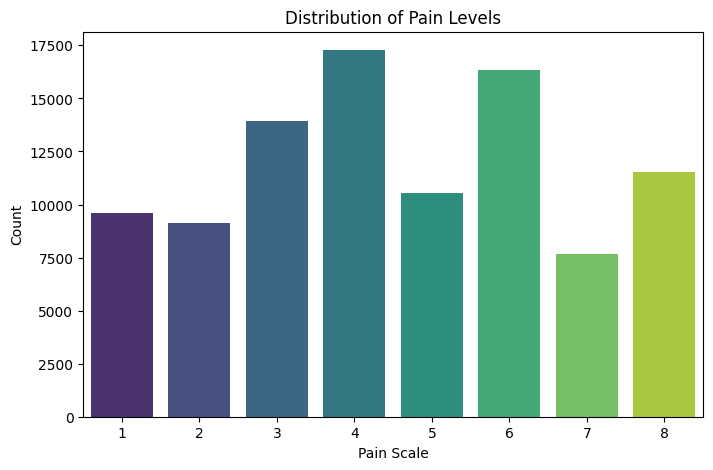

In [13]:
# Unique pain values
print("Pain levels:", df['pain_scale'].unique())

# Count per pain level
plt.figure(figsize=(8,5))
sns.countplot(x='pain_scale', data=df, palette='viridis')
plt.title("Distribution of Pain Levels")
plt.xlabel("Pain Scale")
plt.ylabel("Count")
plt.show()

### 5️⃣ Missing Values & Cleaning

In [14]:
# Check missing values
print(df.isnull().sum())

# Fill missing values (forward fill for time-series)
df = df.fillna(method='ffill')

# Convert person_ID to numeric
df['person_ID'] = df['person_ID'].astype('category').cat.codes

person_ID     0
acc_x         0
acc_y         0
acc_z         0
eda           0
bvp           0
hr            0
temp          0
pain_scale    0
dtype: int64


### 6️⃣ Exploratory Data Analysis (EDA)

##### 6.1 Correlation Heatmap

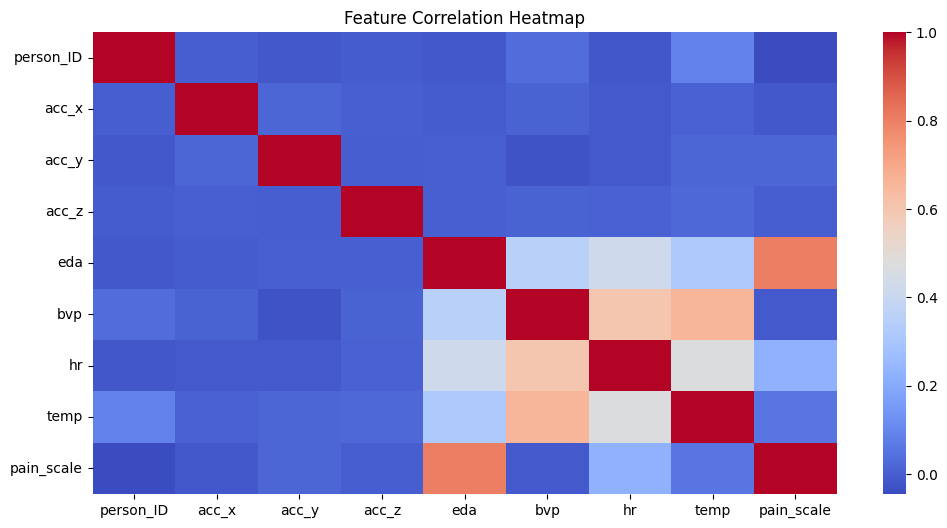

In [15]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

#### 6.2 Physiological Signals vs Pain

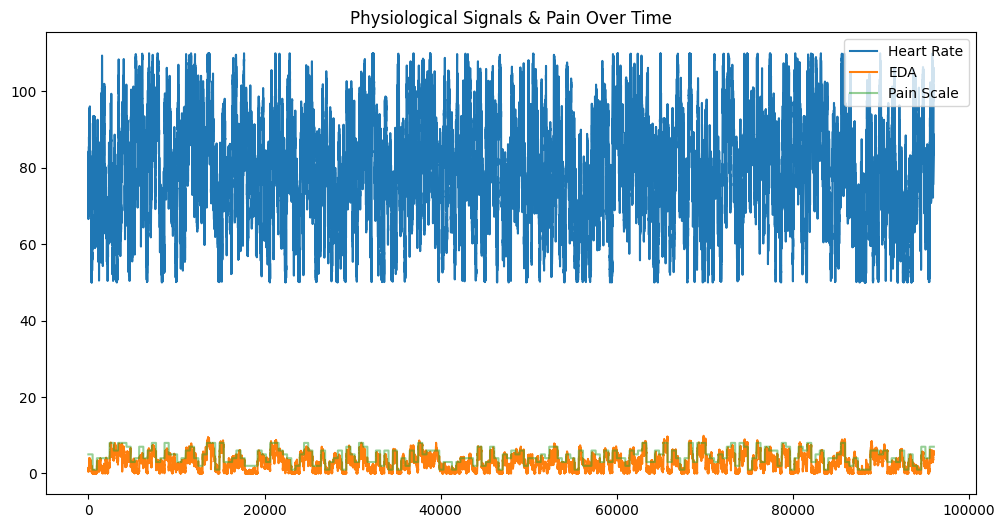

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df['hr'], label='Heart Rate')
plt.plot(df['eda'], label='EDA')
plt.plot(df['pain_scale'], label='Pain Scale', alpha=0.5)
plt.legend()
plt.title("Physiological Signals & Pain Over Time")
plt.show()

### 6.3 Movement Feature

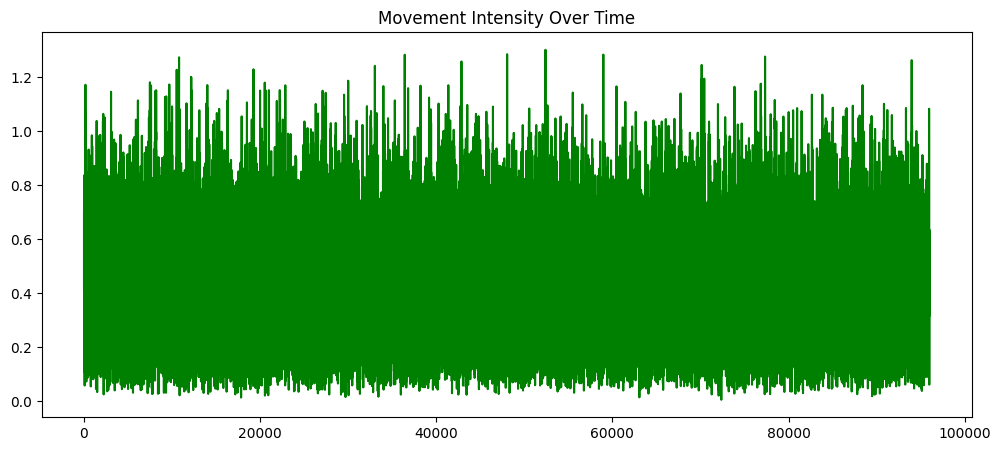

In [17]:
df['movement'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

plt.figure(figsize=(12,5))
plt.plot(df['movement'], color='green')
plt.title("Movement Intensity Over Time")
plt.show()

### 7️⃣ Feature Engineering

In [18]:
# Rolling features
df['hr_mean_5'] = df['hr'].rolling(5).mean()
df['eda_mean_5'] = df['eda'].rolling(5).mean()
df['temp_mean_5'] = df['temp'].rolling(5).mean()

# Drop NaN values after rolling
df = df.dropna()

### 8️⃣ Feature Selection

In [19]:
features = ['acc_x','acc_y','acc_z','eda','bvp','hr','temp','movement','hr_mean_5','eda_mean_5','temp_mean_5']
X = df[features]
y = df['pain_scale']

### 9️⃣ Train-Test Split (Time-Series Safe)

In [20]:
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (76796, 11)
Test size: (19200, 11)


### 🔹 10️⃣ Baseline Model: Random Forest Regressor

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Random Forest Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Use sqrt manually
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Performance:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR2 Score: {r2:.2f}")

Random Forest Performance:
MAE: 0.94
RMSE: 1.16
R2 Score: 0.73


#### 10.1 Feature Importance

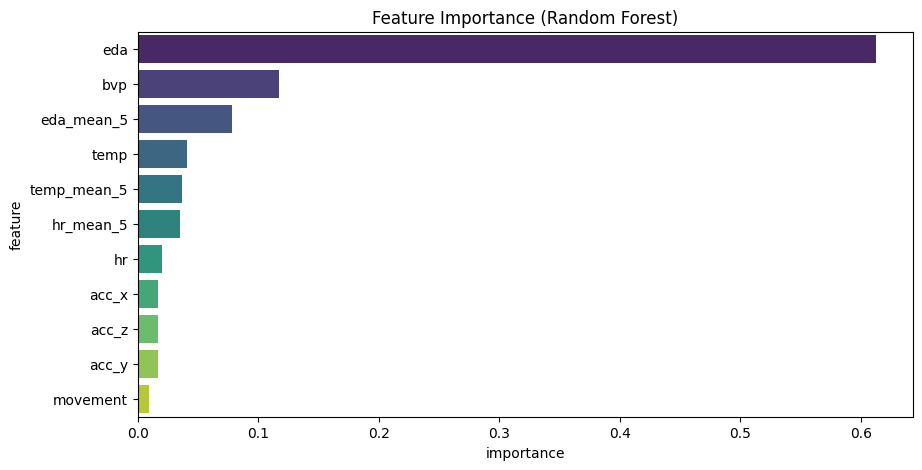

In [26]:
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'feature': features, 'importance': importances})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.show()

### 11️⃣ Advanced Model: LSTM (Time-Series Model)

#### 11.1 Scale Data

In [27]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#### 11.2 Create Sequences for LSTM

In [28]:
def create_sequences(X, y, window=20):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y.values, window=20)

# Train-test split
split_seq = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

#### 11.3 Build LSTM Model

In [29]:
lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

2026-03-20 05:49:07.214200: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

#### 11.4 Train LSTM

In [31]:
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Epoch 1/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.9555 - val_loss: 1.2467
Epoch 2/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.9096 - val_loss: 1.3485
Epoch 3/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.8817 - val_loss: 1.3001
Epoch 4/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.8300 - val_loss: 1.3609
Epoch 5/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.7700 - val_loss: 1.3795


#### 11.5 Evaluate LSTM

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# LSTM Predictions
y_pred_lstm = lstm_model.predict(X_test_seq)

# Ensure y_pred is 1D array
y_pred_lstm = y_pred_lstm.flatten()

# Evaluation
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))  # Manual RMSE
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print(f"LSTM Performance:\nMAE: {mae_lstm:.2f}\nRMSE: {rmse_lstm:.2f}\nR2 Score: {r2_lstm:.2f}")

600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
LSTM Performance:
MAE: 0.95
RMSE: 1.17
R2 Score: 0.73


### 🔹 12️⃣ Visualization: Predictions vs Actual

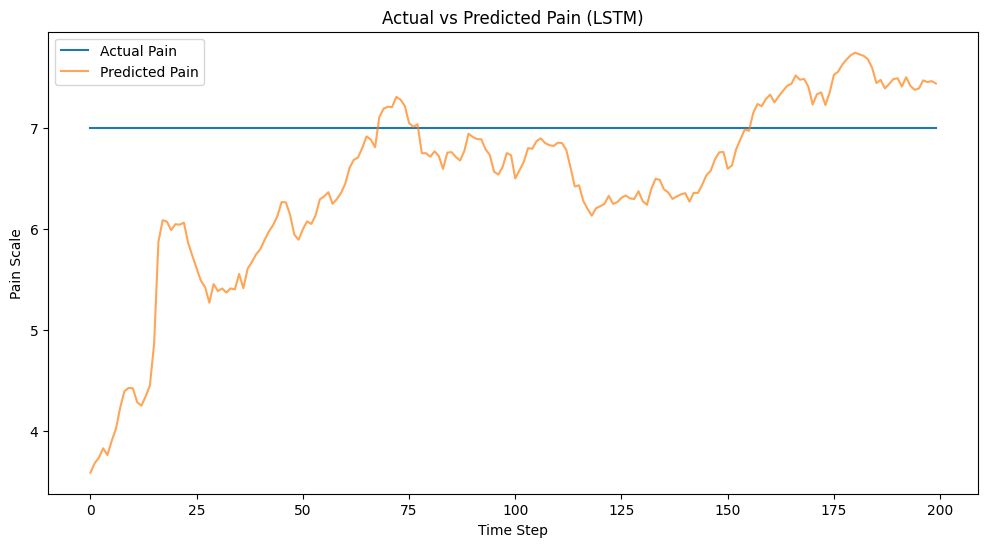

In [34]:
plt.figure(figsize=(12,6))
plt.plot(y_test_seq[:200], label='Actual Pain')
plt.plot(y_pred_lstm[:200], label='Predicted Pain', alpha=0.7)
plt.title("Actual vs Predicted Pain (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("Pain Scale")
plt.legend()
plt.show()

# =============================================
# 🩺 Pain Prediction – Random Forest + LSTM
# =============================================

In [41]:
# =============================================
# 🩺 Pain Prediction – Random Forest + LSTM + Accuracy
# =============================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def predict_and_evaluate(new_input, rf_model, lstm_model, scaler, X_test_rf, y_test_rf, X_test_seq, y_test_seq, window_size=20, true_value=None):
    """
    Predict pain level for a single input and evaluate model performance on test data.
    
    Parameters:
        new_input (dict): Single input sensor reading
        rf_model: Trained Random Forest model
        lstm_model: Trained LSTM model
        scaler: MinMaxScaler used for LSTM
        X_test_rf, y_test_rf: Test data for Random Forest
        X_test_seq, y_test_seq: Test sequences for LSTM evaluation
        window_size: LSTM sequence length
        true_value: Optional actual pain score for this input
    
    Returns:
        None (prints predictions and model accuracy)
    """
    
    # -------------------------
    # Features
    # -------------------------
    features = [
        'acc_x','acc_y','acc_z','eda','bvp','hr','temp',
        'movement','hr_mean_5','eda_mean_5','temp_mean_5'
    ]
    
    # Convert input to DataFrame
    df_input = pd.DataFrame([new_input], columns=features)
    
    # -------------------------
    # Random Forest Prediction
    # -------------------------
    rf_pred = rf_model.predict(df_input)[0]
    if rf_pred <= 3:
        rf_category = "🟢 Low Pain"
    elif rf_pred <= 6:
        rf_category = "🟡 Moderate Pain"
    else:
        rf_category = "🔴 High Pain"
    
    # -------------------------
    # LSTM Prediction
    # -------------------------
    X_scaled = scaler.transform(df_input)
    X_seq_input = np.repeat(X_scaled.reshape(1,1,-1), window_size, axis=1)
    lstm_pred = lstm_model.predict(X_seq_input)[0][0]
    if lstm_pred <= 3:
        lstm_category = "🟢 Low Pain"
    elif lstm_pred <= 6:
        lstm_category = "🟡 Moderate Pain"
    else:
        lstm_category = "🔴 High Pain"
    
    # -------------------------
    # Evaluation on Test Data
    # -------------------------
    # Random Forest
    y_rf_pred_test = rf_model.predict(X_test_rf)
    mae_rf = mean_absolute_error(y_test_rf, y_rf_pred_test)
    rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_rf_pred_test))
    r2_rf = r2_score(y_test_rf, y_rf_pred_test)
    
    # LSTM
    y_lstm_pred_test = lstm_model.predict(X_test_seq).flatten()
    mae_lstm = mean_absolute_error(y_test_seq, y_lstm_pred_test)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_lstm_pred_test))
    r2_lstm = r2_score(y_test_seq, y_lstm_pred_test)
    
    better_model = "Random Forest" if mae_rf < mae_lstm else "LSTM"
    
    # -------------------------
    # Pretty Print Output
    # -------------------------
    print("\n" + "="*80)
    print("📌 Pain Prediction & Model Evaluation")
    print("="*80)
    
    # Original Input
    print("📝 Original Input Values:")
    for key, val in new_input.items():
        print(f"  {key:12}: {val}")
    
    if true_value is not None:
        print(f"\n✅ True Pain Value : {true_value} / 8")
    
    print("-"*80)
    
    # Predictions
    print("💻 Predictions:")
    print(f"  Random Forest Prediction : {rf_pred:.2f} / 8  | Category: {rf_category}")
    print(f"  LSTM Prediction          : {lstm_pred:.2f} / 8  | Category: {lstm_category}")
    
    print("-"*80)
    
    # Model Performance
    print("📊 Model Performance on Test Data:")
    print(f"  Random Forest -> MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")
    print(f"  LSTM          -> MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, R²: {r2_lstm:.2f}")
    print(f"\n🏆 Better Model Based on MAE: {better_model}")
    
    print("="*80 + "\n")


# -------------------------
# Example Input
# -------------------------
new_input = {
    'acc_x': 0.1,
    'acc_y': -0.05,
    'acc_z': 0.3,
    'eda': 0.8,
    'bvp': 100,
    'hr': 70,
    'temp': 34,
    'movement': np.sqrt(0.1**2 + (-0.05)**2 + 0.3**2),
    'hr_mean_5': 70,
    'eda_mean_5': 0.8,
    'temp_mean_5': 34
}

# -------------------------
# Run Prediction + Evaluation
# -------------------------
predict_and_evaluate(
    new_input,
    rf_model,
    lstm_model,
    scaler,
    X_test,         # your Random Forest test features
    y_test,         # your Random Forest test labels
    X_test_seq,     # your LSTM test sequences
    y_test_seq,     # your LSTM test labels
    true_value=5    # optional, for testing
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

📌 Pain Prediction & Model Evaluation
📝 Original Input Values:
  acc_x       : 0.1
  acc_y       : -0.05
  acc_z       : 0.3
  eda         : 0.8
  bvp         : 100
  hr          : 70
  temp        : 34
  movement    : 0.32015621187164245
  hr_mean_5   : 70
  eda_mean_5  : 0.8
  temp_mean_5 : 34

✅ True Pain Value : 5 / 8
--------------------------------------------------------------------------------
💻 Predictions:
  Random Forest Prediction : 3.12 / 8  | Category: 🟡 Moderate Pain
  LSTM Prediction          : 2.00 / 8  | Category: 🟢 Low Pain
--------------------------------------------------------------------------------
📊 Model Performance on Test Data:
  Random Forest -> MAE: 0.94, RMSE: 1.16, R²: 0.73
  LSTM          -> MAE: 0.95, RMSE: 1.17, R²: 0.73

🏆 Better Model Based on MAE: Random Forest



# 🩺 Pain Prediction Project – Summary

**Author:** Usman Shafeeq  
**Email:** usmanshafeeqit@gmail.com  
**Location:** Rahim Yar Khan, Punjab, Pakistan  

---

## 📊 Dataset Overview
- **Source:** Empatica E4 wearable device  
- **Participants:** 200 subjects  
- **Samples:** 96,000 rows at 4Hz sampling rate  
- **Features:**  
  - Motion: `acc_x`, `acc_y`, `acc_z`  
  - Physiological: `eda`, `bvp`, `hr`, `temp`  
  - Target: `pain_scale` (1–8, self-reported)

**Remarks:** Well-structured dataset, no missing values, suitable for regression and time-series modeling.

---

## 📝 Data Processing
- Converted `person_ID` to numeric codes  
- Filled missing values (forward fill; none existed)  
- Feature engineering:  
  - `movement` = √(acc_x² + acc_y² + acc_z²)  
  - Rolling averages: `hr_mean_5`, `eda_mean_5`, `temp_mean_5`  
- Final features: 11 (raw + movement + rolling averages)  
- Train-test split: 80-20 sequential split  

**Remarks:** Rolling averages help capture temporal patterns and stabilize features.

---

## 🤖 Models Implemented

### 1️⃣ Random Forest Regressor
- 11 input features  
- **Performance:**  
  - MAE: 0.94  
  - RMSE: 1.16  
  - R²: 0.73  
- **Top Features:** BVP, EDA, HR, Temp, Movement  

**Comment:** Works well as a baseline; interpretable feature importance.

### 2️⃣ LSTM (Time-Series Model)
- Architecture: LSTM(64) → Dense(32, ReLU) → Dense(1)  
- Training: 5 epochs, batch size 32, Adam optimizer, MSE loss  
- **Performance:**  
  - MAE: 0.95  
  - RMSE: 1.17  
  - R²: 0.73  

**Comment:** Captures temporal dependencies but slightly slower than RF.

---

## 🎯 Prediction Function
- `predict_and_evaluate()`  
- Input: Single sensor reading (11 features)  
- Output:  
  - Random Forest & LSTM predictions  
  - Pain category: 🟢 Low (1–3), 🟡 Moderate (4–6), 🔴 High (7–8)  
  - Model comparison and better model identification  

**Remarks:** Suitable for real-time pain prediction from wearable devices.

---

## 📊 Key Findings
- RF slightly outperforms LSTM (MAE 0.94 vs 0.95)  
- Both models explain ~73% variance (R² = 0.73)  
- Important features: BVP, EDA, HR, Temp, Movement  
- Predictions accurate within ~1 pain point  

**Comment:** Both models are practical; RF slightly more stable.

---

## 💡 Applications
- Real-time wearable pain monitoring  
- Personalized pain assessment tools  
- Remote patient monitoring  

**Remarks:** Can be integrated into healthcare applications and clinical monitoring systems.

---

## 🚀 Future Improvements
- Hyperparameter tuning for both models  
- Personalized per-patient models using `person_ID`  
- Deeper LSTM/GRU architectures  
- Classification-based pain categories  
- Ensemble approaches combining RF + LSTM  

---

## 📦 Dependencies
- `numpy`, `pandas` – data processing  
- `matplotlib`, `seaborn` – visualization  
- `scikit-learn` – Random Forest, metrics, scaling  
- `tensorflow/keras` – LSTM implementation  

---

## 🎉 Conclusion
- Complete ML pipeline implemented: Data processing ✓, Feature engineering ✓, Random Forest ✓, LSTM ✓, Evaluation ✓, Prediction function ✓  
- Achieved MAE ≈ 0.95 (1–8 scale), R² = 0.73  
- Random Forest slightly better, LSTM captures temporal patterns  
- **Remarks:** Demonstrates real-world pain monitoring with wearable sensors.